Topic 2-Machine Learning - Linear Regression

Q1. Dataset Loading

Load the Diabetes Dataset using Scikit-learn and display the first 10 records, dataset shape, feature names, and target variable.

In [3]:
import pandas as pd
from sklearn.datasets import load_diabetes

df_X, series_y = load_diabetes(as_frame=True, return_X_y=True)
y = pd.DataFrame([series_y]).T

In [18]:
df_X.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504


In [19]:
df_X.shape

(442, 10)

In [26]:

df_X.columns.to_list()

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [25]:
y.head()

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


Q2. Exploratory Data Analysis (EDA)

    Perform Exploratory Data Analysis (EDA) by:

    Checking data types
    Identifying missing values
    Displaying statistical summary
    Finding duplicate records

In [30]:
df_X.dtypes

age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object

In [40]:
df_X.isnull().sum()


age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

In [41]:
display(df_X.describe())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [42]:
df_X.duplicated().sum()

np.int64(0)

Q3. Data Visualization

    Create the following visualizations:

    Histogram
    Correlation Heatmap
    Scatter Plot (between the most correlated feature and the target variable)
    Write your observations for each visualization

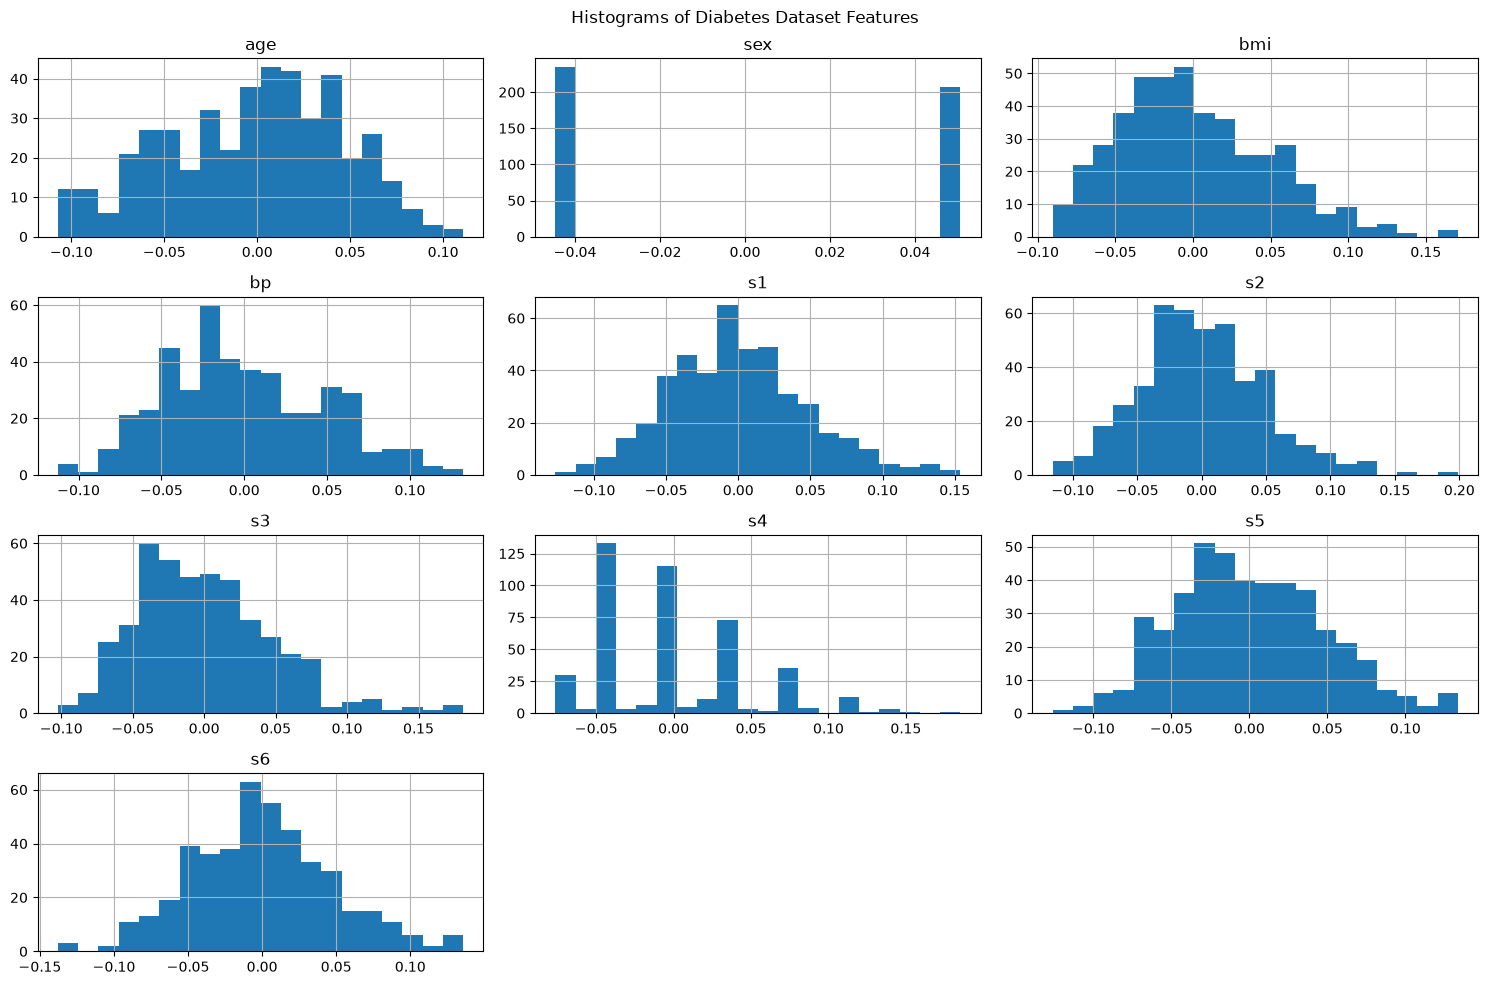

In [46]:
import matplotlib.pyplot as plt

df_X.hist(figsize=(15,10),bins=20)
plt.suptitle("Histograms of Diabetes Dataset Features")
plt.tight_layout()
plt.show()

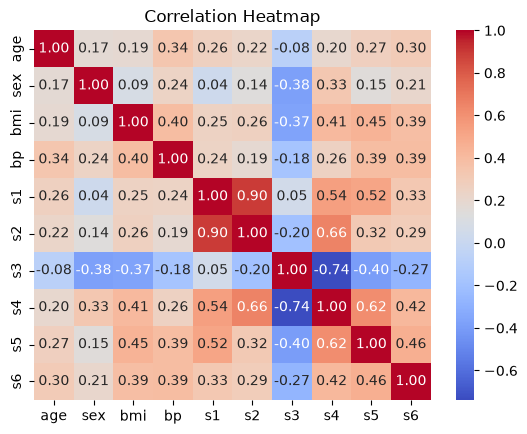

In [49]:
import seaborn as sns
plt.Figure(figsize=(12,8))
sns.heatmap(df_X.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [61]:
df=df_X.copy()
df['target']=series_y

print(df.columns)

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='str')


In [63]:
correlation = df.corr()['target'].drop('target').sort_values(ascending=False)

print("Correlation with Target:")
print(correlation)

Correlation with Target:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


In [64]:
most_correlated_feature = correlation.abs().idxmax()

print("Most Correlated Feature:", most_correlated_feature)
print("Correlation Value:", df[most_correlated_feature].corr(df['target']))

Most Correlated Feature: bmi
Correlation Value: 0.5864501344746885


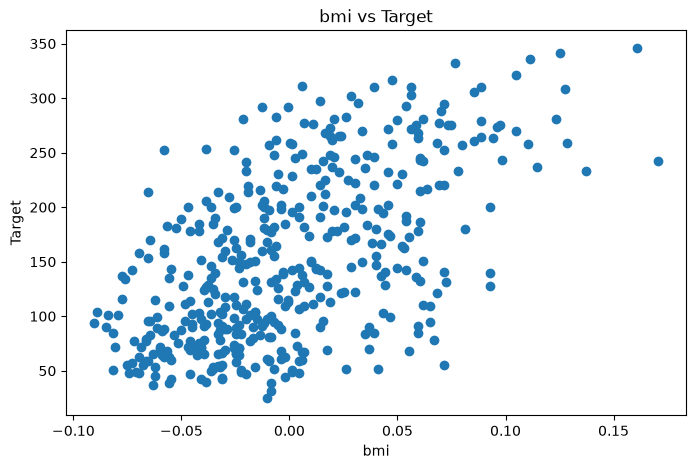

In [65]:
plt.figure(figsize=(8, 5))

plt.scatter(df[most_correlated_feature], df['target'])

plt.xlabel(most_correlated_feature)
plt.ylabel("Target")
plt.title(f"{most_correlated_feature} vs Target")

plt.show()

Q4. Data Preprocessing

Prepare the dataset by:

    Separating features (X) and target (y)
    Splitting the data into 80% training and 20% testing sets
    Applying feature scaling using StandardScaler (SKIP THIS STEP)

In [71]:
X = df_X
y = series_y

print("Features (X):")
display(X.head())

print("Target (y):")
display(y.head())

Features (X):


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


Target (y):


0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (353, 10)
Testing Data Shape: (89, 10)


Q5. Model Training

Build a Linear Regression model using the training dataset and display the model coefficients and intercept.



In [73]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [74]:
print("Model Coefficients:")

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

display(coefficients)

Model Coefficients:


,Feature,Coefficient
0,age,37.904021
1,sex,-241.964362
2,bmi,542.428759
3,bp,347.703844
4,s1,-931.488846
5,s2,518.062277
6,s3,163.419983
7,s4,275.317902
8,s5,736.198859
9,s6,48.670657


In [75]:
print("Intercept:", model.intercept_)

Intercept: 151.34560453985995


Q6. Prediction

Predict the target values for the testing dataset and display a comparison of the Actual and Predicted values.



predict test values

In [77]:
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858
  94.13865744 168.43486358  53.5047888  206.63081659 100.12925869
 130.66657085 219.53071499 250.7803234  196.3688346  218.57511815
 207.35050182  88.48340941  70.43285917 188.95914235 154.8868162
 159.36170122 188.31263363 180.39094033  47.99046561 108.97453871
 174.77897633  86.36406656 132.95761215 184.53819483 173.83220911
 190.35858492 124.4156176  119.65110656 147.95168682  59.05405241
  71.62331856 107.68284704 165.45365458 155.00975931 171.04799096
  61.45761356  71.66672581 114.96732206  51.57975523 167.57599528
 152.52291955  62.95568515 103.49741722 109.20751489 175.64118426
 154.60296242  94.41704366 210.74209145 120.2566205   77.61585399
 187.93203995 206.49337474 140.63167076 105.59678023 130.70432536
 202.18534537 171.13039501 164.91423047 124.72472569 144.81030894
 181.99635452 199.41369642 234.21436188 145.95665512  79.86

actual vs predicted

In [78]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

display(comparison.head(10))

,Actual,Predicted
0,219.0,139.547558
1,70.0,179.517208
2,202.0,134.038756
3,230.0,291.417029
4,111.0,123.789659
5,84.0,92.172347
6,242.0,258.232389
7,272.0,181.337321
8,94.0,90.224113
9,96.0,108.633759


Actual vs pridicted visualization

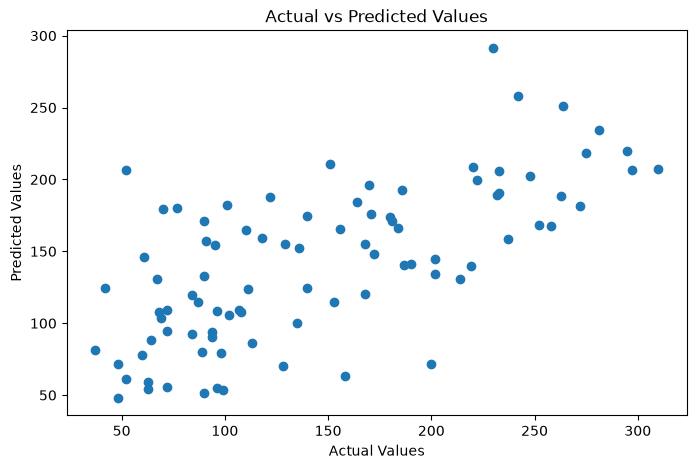

In [79]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.show()

Q7. Model Evaluation

Evaluate the model using:

    Mean Absolute Error (MAE)
    Mean Squared Error (MSE)
    Root Mean Squared Error (RMSE)
    R² Score
    Interpret the results.

In [81]:

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R-squared
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)

Mean Absolute Error (MAE): 42.79409467959994
Mean Squared Error (MSE): 2900.1936284934804
Root Mean Squared Error (RMSE): 53.85344583676592
R-squared (R²): 0.4526027629719197


Q9. Feature Analysis

Identify the most influential feature based on the regression coefficients and explain how it affects the target variable.

In [82]:
# Create a dataframe of coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

# Sort by absolute coefficient value
coef_df['Absolute_Coefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

display(coef_df)

,Feature,Coefficient,Absolute_Coefficient
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
5,s2,518.062277,518.062277
3,bp,347.703844,347.703844
7,s4,275.317902,275.317902
1,sex,-241.964362,241.964362
6,s3,163.419983,163.419983
9,s6,48.670657,48.670657
0,age,37.904021,37.904021


Find the most influential feature

In [83]:
most_influential = coef_df.iloc[0]

print("Most Influential Feature:", most_influential['Feature'])
print("Coefficient:", most_influential['Coefficient'])

Most Influential Feature: s1
Coefficient: -931.4888458835161


    Observation: The feature with the highest absolute regression coefficient is the most influential feature in the Linear Regression model. A positive coefficient means that an increase in the feature is associated with an increase in the target variable, while a negative coefficient means that an increase in the feature is associated with a decrease in the target variable, keeping other features constant.